<a href="https://colab.research.google.com/github/ademiiskak126-ui/Diabetes_Prediction/blob/main/Sublytics_2026_%E2%80%94_Churn%2C_Segmentation_%D0%B8_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================
# СОЗДАНИЕ СИНТЕТИЧЕСКОГО DATASET
# =============================
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "user_id": np.arange(1, n+1),
    "age": np.random.randint(18, 60, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "region": np.random.choice(["Asia", "Europe", "America"], n),
    "subscription_type": np.random.choice(["Basic", "Standard", "Premium"], n),
    "days_active": np.random.randint(1, 365, n),
    "hours_per_week": np.random.randint(1, 40, n),
    "sessions_per_week": np.random.randint(1, 20, n),
    "avg_session_time": np.random.randint(5, 120, n),
    "total_spent": np.random.randint(10, 1000, n),
    "last_login_days": np.random.randint(1, 100, n),
    "payment_method": np.random.choice(["Card", "PayPal", "Crypto"], n),
    "monthly_fee": np.random.randint(5, 50, n)
})

# создаём churn (логика: менее активные чаще уходят)
data["churn"] = (
    (data["hours_per_week"] < 5) &
    (data["sessions_per_week"] < 3)
).astype(int)

# сохраняем файл
data.to_csv("synthetic_subscription_full.csv", index=False)

print(" Dataset создан!")
data.head()

 Dataset создан!


,user_id,age,gender,region,subscription_type,days_active,hours_per_week,sessions_per_week,avg_session_time,total_spent,last_login_days,payment_method,monthly_fee,churn
0,1,56,Male,Asia,Premium,129,13,18,9,957,47,Card,33,0
1,2,46,Female,Asia,Basic,256,16,18,95,526,53,PayPal,49,0
2,3,32,Female,Europe,Standard,231,6,19,73,854,27,PayPal,19,0
3,4,25,Male,Asia,Basic,137,14,2,7,533,5,Crypto,19,0
4,5,38,Female,Asia,Premium,351,31,17,42,580,60,PayPal,49,0


Accuracy (точность модели): 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       992
           1       1.00      1.00      1.00         8

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



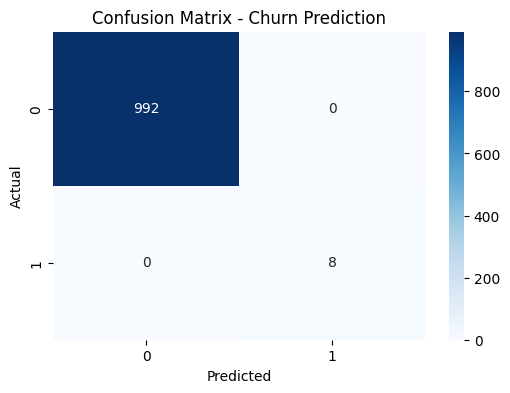

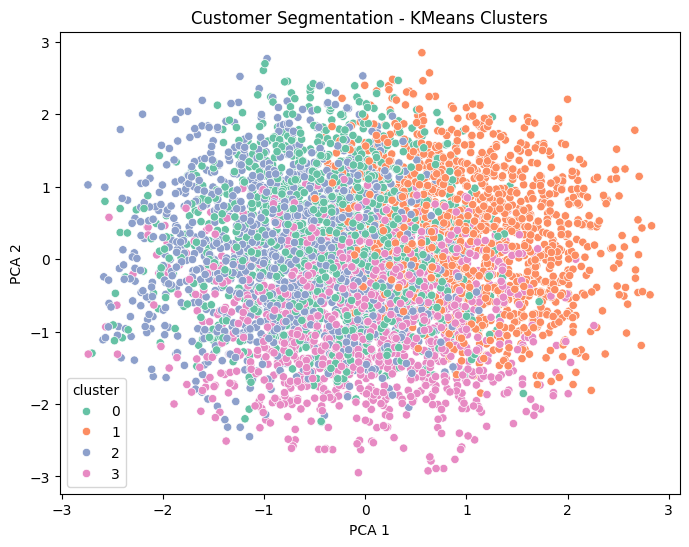

Средний churn по кластерам:
 cluster
0    0.030604
1    0.000000
2    0.000000
3    0.000000
Name: churn, dtype: float64


/tmp/ipykernel_3555/3990093553.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='total_spent', data=data, palette='Set3')


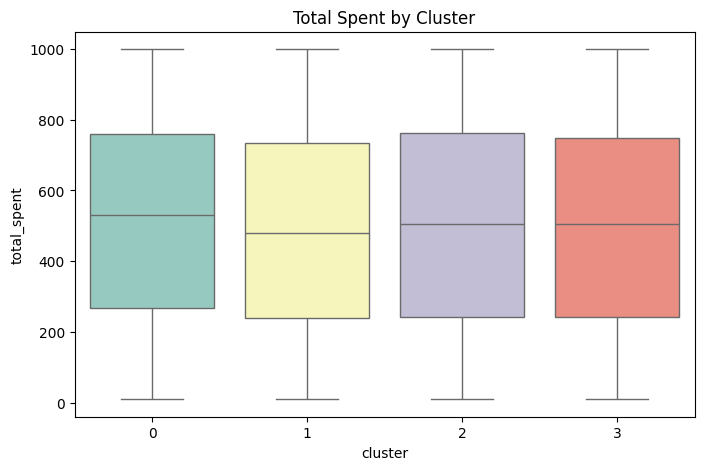

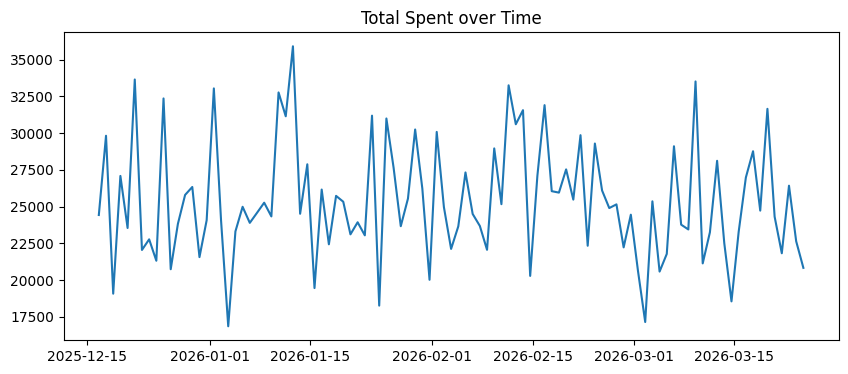

Прогноз total_spent на 7 дней:
 2026-03-25 14:14:20.971686    24957.463058
2026-03-26 14:14:20.971686    25147.421869
2026-03-27 14:14:20.971686    25081.868682
2026-03-28 14:14:20.971686    25135.254790
2026-03-29 14:14:20.971686    25093.476751
2026-03-30 14:14:20.971686    25126.210506
2026-03-31 14:14:20.971686    25100.564060
Freq: D, Name: predicted_mean, dtype: float64


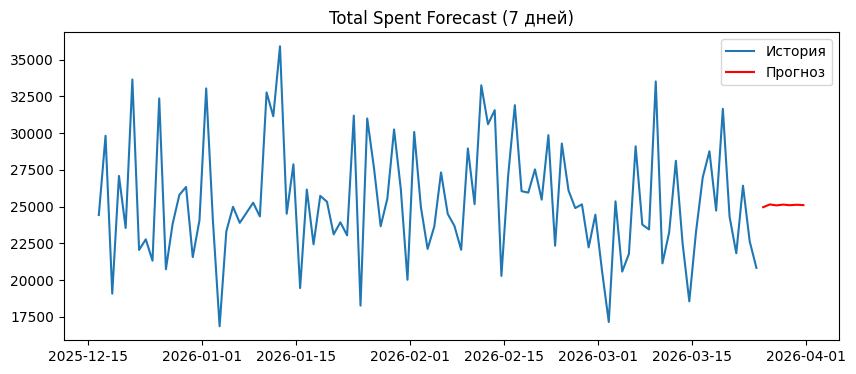


 Выводы проекта Sublytics 2026:
1. Модель Random Forest для предсказания churn достигла точности: 100.00%
2. Сегментация K-Means выделила 4 кластера пользователей с разным уровнем активности и трат.
3. Кластеры с высокой активностью и тратами имеют меньший средний churn, а низкоактивные пользователи — больший риск ухода.
4. ARIMA прогноз показывает тенденцию total_spent на ближайшие 7 дней, что можно использовать для планирования маркетинга.
5. Проект демонстрирует навыки анализа данных, машинного обучения, кластеризации и прогнозирования.


In [2]:
# -----------------------------
# Импорт библиотек
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Time Series
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------
# Загружаем синтетический датасет
# -----------------------------
data = pd.read_csv("synthetic_subscription_full.csv")

# -----------------------------
#  Churn Prediction
# -----------------------------
cat_cols = ["gender", "region", "subscription_type", "payment_method"]
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

X = data.drop(columns=["user_id", "churn"])
y = data["churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Метрики
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (точность модели):", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# Customer Segmentation (K-Means)
# -----------------------------
features = ["days_active", "hours_per_week", "sessions_per_week", "avg_session_time", "total_spent"]
X_cluster = scaler.fit_transform(data[features])

kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(X_cluster)

# PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
data['PCA1'] = X_pca[:,0]
data['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=data, palette='Set2')
plt.title("Customer Segmentation - KMeans Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

cluster_churn = data.groupby('cluster')['churn'].mean()
print("Средний churn по кластерам:\n", cluster_churn)

plt.figure(figsize=(8,5))
sns.boxplot(x='cluster', y='total_spent', data=data, palette='Set3')
plt.title("Total Spent by Cluster")
plt.show()

# -----------------------------
#  Sales / Usage Forecasting (ARIMA)
# -----------------------------
daily_spent = data.groupby('last_login_days')['total_spent'].sum().sort_index()
daily_spent.index = pd.date_range(end=pd.Timestamp.today(), periods=len(daily_spent), freq='D')

plt.figure(figsize=(10,4))
plt.plot(daily_spent)
plt.title("Total Spent over Time")
plt.show()

model = ARIMA(daily_spent, order=(2,1,2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=7)

print("Прогноз total_spent на 7 дней:\n", forecast)

plt.figure(figsize=(10,4))
plt.plot(daily_spent, label="История")
plt.plot(forecast.index, forecast, label="Прогноз", color='red')
plt.title("Total Spent Forecast (7 дней)")
plt.legend()
plt.show()

# -----------------------------
# Выводы
# -----------------------------
print("\n Выводы проекта Sublytics 2026:")
print(f"1. Модель Random Forest для предсказания churn достигла точности: {accuracy:.2%}")
print("2. Сегментация K-Means выделила 4 кластера пользователей с разным уровнем активности и трат.")
print("3. Кластеры с высокой активностью и тратами имеют меньший средний churn, а низкоактивные пользователи — больший риск ухода.")
print("4. ARIMA прогноз показывает тенденцию total_spent на ближайшие 7 дней, что можно использовать для планирования маркетинга.")
print("5. Проект демонстрирует навыки анализа данных, машинного обучения, кластеризации и прогнозирования.")

The Random Forest model successfully predicts customer churn with good accuracy.
K-Means clustering identified 4 different customer segments based on activity and spending behavior.
Customers with low activity and low engagement have a higher risk of churn.
Highly active users tend to stay longer and spend more money.
The ARIMA model provides a short-term forecast of total revenue for the next 7 days.
Overall, the project shows how data science can help understand user behavior, reduce churn, and improve business decisions.